In [61]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [62]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [63]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [64]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [115]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# squash the weights. Multiply by gain (5/3 for tanh) over sqrt(fan_in) where fan_in is the number of input elements
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/(n_embd * block_size)**0.5 
# b1 = torch.randn(n_hidden,                        generator=g) * 0.01 # add a little bit of bias to the weights
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0 # don't want to add bias to random numbers at initialization

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.ones((1, n_hidden))
bnstd_running = torch.zeros((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


tensor(0.0054) tensor(0.9986)
tensor(0.0004) tensor(0.9975)


(array([9.42931510e-05, 9.42931510e-05, 1.88586302e-04, 1.88586302e-04,
        5.18612330e-04, 1.24938425e-03, 1.83871644e-03, 2.49876850e-03,
        5.32756303e-03, 7.92062468e-03, 1.27531487e-02, 2.03673206e-02,
        3.17060720e-02, 4.72172953e-02, 6.75610427e-02, 9.87720756e-02,
        1.34721339e-01, 1.82622260e-01, 2.34577786e-01, 2.93345993e-01,
        3.53104277e-01, 3.91458016e-01, 4.22268303e-01, 4.22409743e-01,
        4.02113142e-01, 3.55626619e-01, 3.07395672e-01, 2.47660961e-01,
        1.93465972e-01, 1.46060091e-01, 1.05608329e-01, 7.55759605e-02,
        5.28277378e-02, 3.45584398e-02, 2.31961151e-02, 1.43797055e-02,
        8.55710345e-03, 6.55337399e-03, 3.53599316e-03, 1.93300959e-03,
        1.53226370e-03, 6.36478769e-04, 2.12159590e-04, 2.12159590e-04,
        7.07198632e-05, 4.71465755e-05, 0.00000000e+00, 4.71465755e-05,
        2.35732877e-05, 2.35732877e-05]),
 array([-4.90364408, -4.6915396 , -4.47943512, -4.26733064, -4.05522615,
        -3.84312167, 

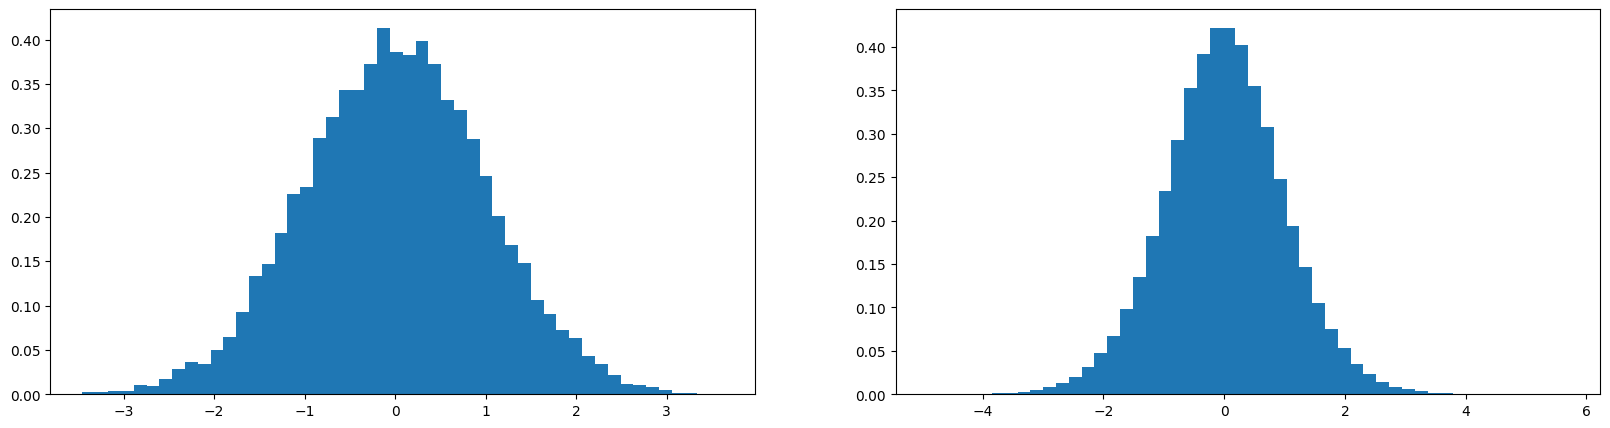

In [116]:
# analysis: matrix multiplication of two normally distributed matrices causes the new matrix to have a wider standard deviation
# however we want a roughly unit gaussian throughout the neural net
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5 # normalize y by dividing w by sqrt(fan_in) where fan_in is the number of input elements
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

In [117]:
hpreact.shape

torch.Size([182625, 200])

In [118]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [119]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

In [120]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 # + b1 # hidden layer pre-activation
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / (bnstdi + 0.0001) + bnbias # normalizing the preactivations only at initialization

  with torch.no_grad():
      bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
      bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  #break

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3674
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9312
 140000/ 200000: 2.2232
 150000/ 200000: 2.0027
 160000/ 200000: 2.0996
 170000/ 200000: 2.4949
 180000/ 200000: 2.0198
 190000/ 200000: 2.1707


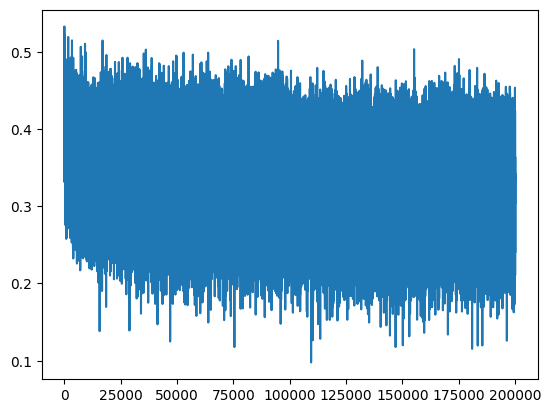

In [121]:
plt.plot(lossi)

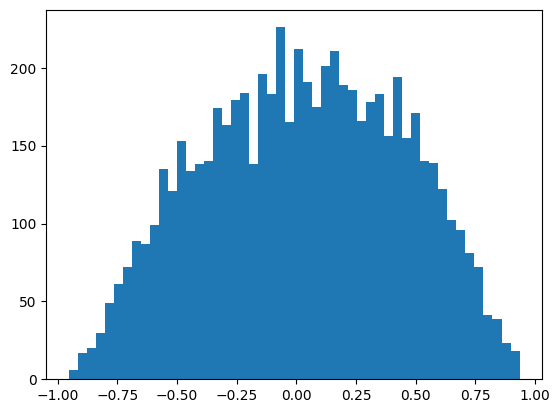

In [47]:
# post activation (after going through tanh function) => Shows our tanh is very active meaning most values go to the ends of the function
plt.hist(h.view(-1).tolist(), 50); # converting all the outputs of the hidden layer to a list to then visualize where the data lies

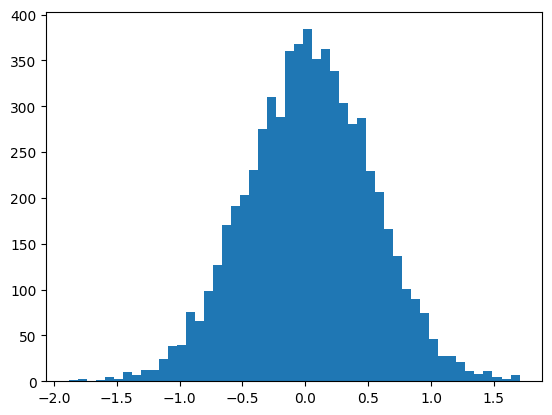

In [48]:
# pre activation (before passing through tanh function) => very broad 
# this is not good, 
plt.hist(hpreact.view(-1).tolist(), 50);

In [49]:
# what the two previous graphs show is that backpropogation is not very effective since our values end up on the tail ends of tanh
# this means we require more changes to our parameters to efficiently modify our loss since small changes will not move us a lot on the tail ends of tanh
# gradient is basically zero at these ends
# gradients flowing through the network get destroyed at these ends

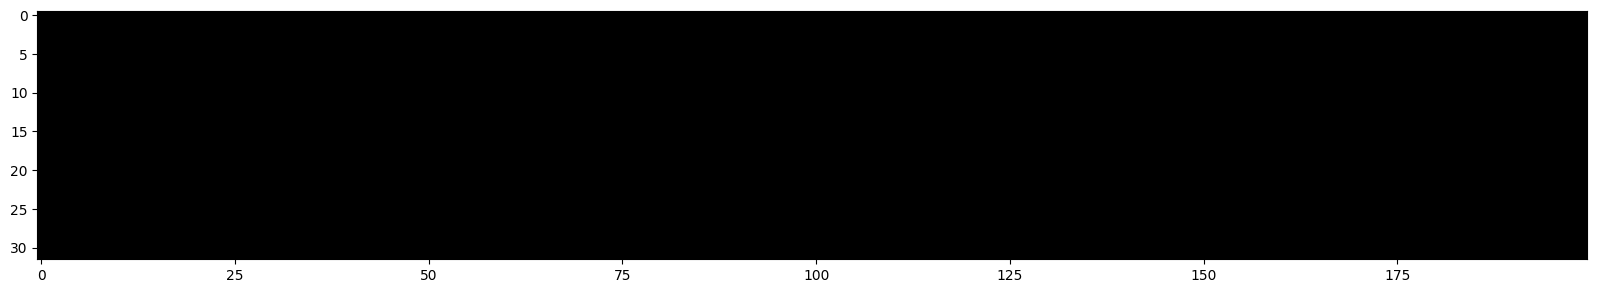

In [50]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest') # 32 examples, 200 hidden neurons
# each white part shows a part of a neuron where the backward gradient gets destroyed
# a whole column of white means there is a dead neuron, meaning no example will ever activate the function

In [9]:
# Our intial loss is high
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [11]:
# 4-dimensional example of the issue
# logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.randn(4)
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([ 0.4428,  1.2353, -0.4949,  0.5353]),
 tensor([0.2129, 0.4702, 0.0834, 0.2335]),
 tensor(2.4847))

In [122]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [123]:
bnmean

tensor([[-2.3951,  0.3697, -1.2721,  1.2946,  0.9557,  0.9956,  1.5505, -1.9209,
          1.1122,  1.2443, -1.8120, -2.7732,  0.0740, -0.6076,  0.4334, -0.6824,
          0.7747, -2.1874, -0.1997,  1.5906, -0.8759,  0.0856, -0.2509,  0.4103,
          1.0315,  1.6303,  1.1982,  0.9553,  0.3585,  1.9512, -0.0683, -1.2068,
         -0.1048, -0.2659, -0.4750, -1.4983, -2.6133,  0.0535, -0.0118,  0.6009,
         -0.2271, -0.8904, -0.2850, -0.1836,  0.6519,  0.8989,  1.5830, -0.3834,
          1.9893,  1.0678,  1.7157, -0.7877,  2.0548,  0.3595,  0.5521, -1.9211,
         -0.0324,  0.7198,  0.8939, -0.7949, -0.6655,  0.9820,  0.4984,  0.2978,
          1.1427,  1.6460, -1.3207,  2.4311, -0.5222,  0.4783, -1.0088,  0.2360,
          1.0445, -1.5623, -3.0713,  0.6018,  0.7533, -0.0513,  0.4650,  0.7591,
          0.2517,  1.2639,  1.4014,  0.5570, -0.2060, -0.0652, -1.3351,  0.5008,
          0.1291, -0.4667, -0.3976,  1.4660, -1.1291, -0.8737, -0.9942,  0.2943,
         -0.3022,  0.1406,  

In [124]:
bnmean_running

tensor([[-2.4077e+00,  3.7336e-01, -1.2685e+00,  1.2964e+00,  9.6900e-01,
          9.8380e-01,  1.5425e+00, -1.9248e+00,  1.1059e+00,  1.2246e+00,
         -1.8298e+00, -2.7719e+00,  7.1518e-02, -6.1835e-01,  4.3351e-01,
         -6.6878e-01,  7.7055e-01, -2.1872e+00, -2.1864e-01,  1.5705e+00,
         -8.6612e-01,  1.0756e-01, -2.3925e-01,  4.1453e-01,  1.0353e+00,
          1.6322e+00,  1.1984e+00,  9.5770e-01,  3.5316e-01,  1.9481e+00,
         -8.0588e-02, -1.2022e+00, -9.7793e-02, -2.6642e-01, -4.7089e-01,
         -1.4911e+00, -2.6119e+00,  4.7213e-02,  2.0409e-05,  6.0426e-01,
         -2.3626e-01, -9.1302e-01, -2.8284e-01, -1.7862e-01,  6.5149e-01,
          9.0377e-01,  1.5863e+00, -3.9478e-01,  1.9727e+00,  1.0565e+00,
          1.7168e+00, -7.9498e-01,  2.0449e+00,  3.5584e-01,  5.5005e-01,
         -1.9196e+00, -3.1622e-02,  7.1288e-01,  9.0183e-01, -7.9927e-01,
         -6.7680e-01,  9.6937e-01,  4.8917e-01,  2.9614e-01,  1.1422e+00,
          1.6289e+00, -1.3292e+00,  2.

In [125]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674149990081787
val 2.1056854724884033


loss log
original:
train 2.1245384216308594 val 2.168196439743042

fix softmax confidently wrong:
train 2.07 val 2.13

fix tanh layer too saturated at init:
train 2.0355966091156006 val 2.1026785373687744

use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693 val 2.106989622116089

add batch norm layer
train 2.0668270587921143 val 2.104844808578491